In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib
import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries loaded!")

✅ Libraries loaded!


In [36]:
X_train = pd.read_csv('../data/processed/X_train.csv')
X_test  = pd.read_csv('../data/processed/X_test.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').squeeze()
y_test  = pd.read_csv('../data/processed/y_test.csv').squeeze()

print("✅ Data loaded!")
print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)

✅ Data loaded!
X_train shape: (171, 8)
X_test shape : (43, 8)


In [37]:
# Model 1: Linear Regression (baseline)
lr = LinearRegression()
lr.fit(X_train, y_train)
print("✅ Linear Regression trained!")

# Model 2: Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
print("✅ Random Forest trained!")

# Model 3: XGBoost
xgb = XGBRegressor(n_estimators=200, learning_rate=0.05, 
                   max_depth=5, random_state=42)
xgb.fit(X_train, y_train)
print("✅ XGBoost trained!")

✅ Linear Regression trained!
✅ Random Forest trained!
✅ XGBoost trained!


In [41]:
def evaluate_model(name, model, X_test, y_test):
    preds = model.predict(X_test)
    mae   = mean_absolute_error(y_test, preds)
    rmse  = np.sqrt(mean_squared_error(y_test, preds))
    r2    = r2_score(y_test, preds)
    
    print(f"\n{'='*40}")
    print(f"  {name}")
    print(f"{'='*40}")
    print(f"  MAE  : {mae:.4f} kg/capita")
    print(f"  RMSE : {rmse:.4f} kg/capita")
    print(f"  R²   : {r2:.4f}")
    
    return {'Model': name, 'MAE': mae, 'RMSE': rmse, 'R2': r2}

results = []
# Removed Linear Regression — mathematically trivial for this dataset
results.append(evaluate_model("Random Forest", rf,  X_test, y_test))
results.append(evaluate_model("XGBoost",       xgb, X_test, y_test))


  Random Forest
  MAE  : 3.8863 kg/capita
  RMSE : 7.8641 kg/capita
  R²   : 0.8575

  XGBoost
  MAE  : 2.3697 kg/capita
  RMSE : 5.2393 kg/capita
  R²   : 0.9368


In [42]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('R2', ascending=False)
results_df = results_df.round(4)

print("\n📊 MODEL COMPARISON TABLE")
print(results_df.to_string(index=False))


📊 MODEL COMPARISON TABLE
        Model    MAE   RMSE     R2
      XGBoost 2.3697 5.2393 0.9368
Random Forest 3.8863 7.8641 0.8575


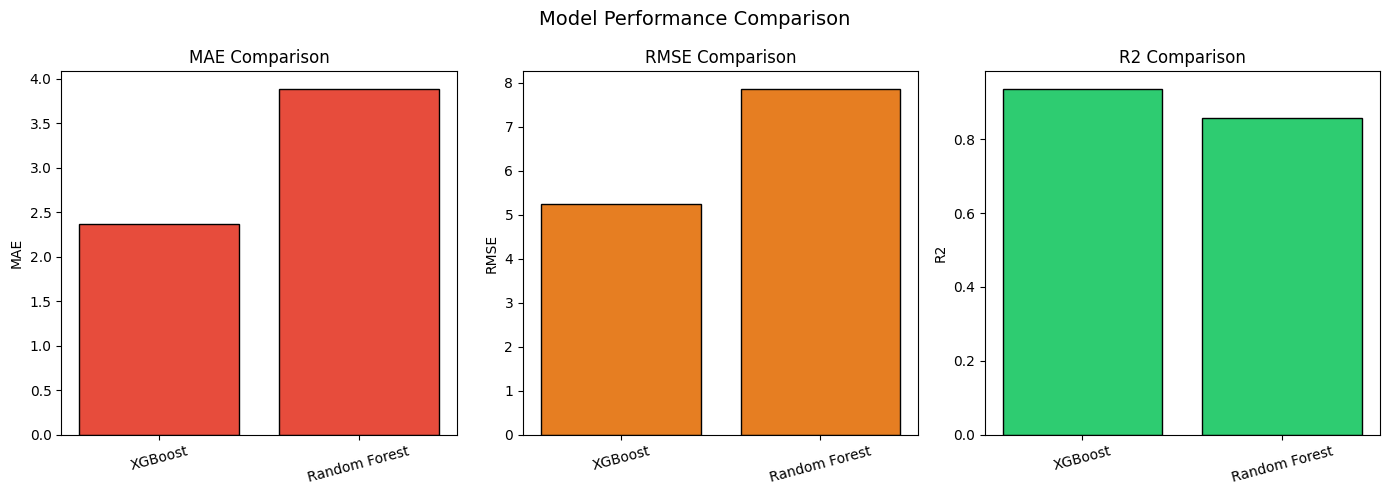

✅ Comparison chart saved!


In [43]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
metrics = ['MAE', 'RMSE', 'R2']
colors  = ['#e74c3c', '#e67e22', '#2ecc71']

for i, metric in enumerate(metrics):
    axes[i].bar(results_df['Model'], results_df[metric], 
                color=colors[i], edgecolor='black')
    axes[i].set_title(f'{metric} Comparison', fontsize=12)
    axes[i].set_ylabel(metric)
    axes[i].tick_params(axis='x', rotation=15)

plt.suptitle('Model Performance Comparison', fontsize=14)
plt.tight_layout()
plt.savefig('../data/processed/model_comparison.png')
plt.show()
print("✅ Comparison chart saved!")

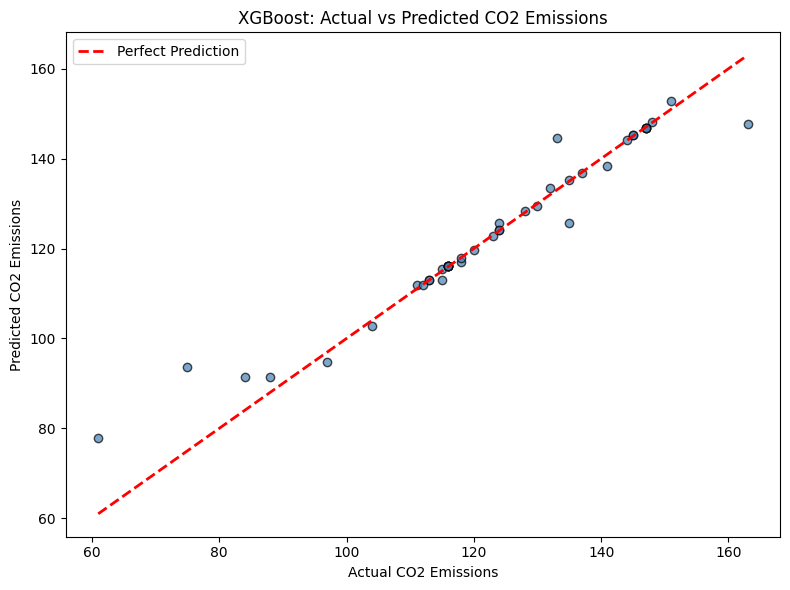

✅ Actual vs Predicted plot saved!


In [44]:
# Use XGBoost predictions
xgb_preds = xgb.predict(X_test)

plt.figure(figsize=(8, 6))
plt.scatter(y_test, xgb_preds, color='steelblue', 
            alpha=0.7, edgecolors='black')

# Perfect prediction line
min_val = min(y_test.min(), xgb_preds.min())
max_val = max(y_test.max(), xgb_preds.max())
plt.plot([min_val, max_val], [min_val, max_val], 
         'r--', linewidth=2, label='Perfect Prediction')

plt.xlabel('Actual CO2 Emissions')
plt.ylabel('Predicted CO2 Emissions')
plt.title('XGBoost: Actual vs Predicted CO2 Emissions')
plt.legend()
plt.tight_layout()
plt.savefig('../data/processed/actual_vs_predicted.png')
plt.show()
print("✅ Actual vs Predicted plot saved!")

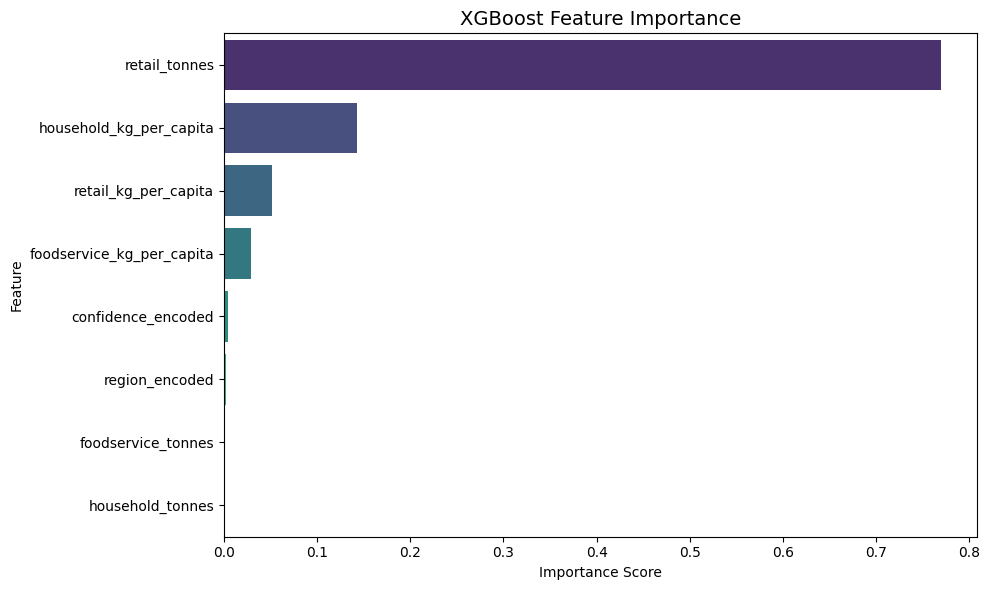


📊 Feature Importance Rankings:
                  Feature  Importance
            retail_tonnes    0.769593
  household_kg_per_capita    0.142433
     retail_kg_per_capita    0.051076
foodservice_kg_per_capita    0.029462
       confidence_encoded    0.004213
           region_encoded    0.002066
       foodservice_tonnes    0.000904
         household_tonnes    0.000252


In [45]:
feat_importance = pd.DataFrame({
    'Feature'   : X_train.columns,
    'Importance': xgb.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=feat_importance, x='Importance', 
            y='Feature', palette='viridis')
plt.title('XGBoost Feature Importance', fontsize=14)
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('../data/processed/feature_importance.png')
plt.show()

print("\n📊 Feature Importance Rankings:")
print(feat_importance.to_string(index=False))

In [46]:
# Save all 3 models
joblib.dump(lr,  '../models/linear_regression.pkl')
joblib.dump(rf,  '../models/random_forest.pkl')
joblib.dump(xgb, '../models/xgboost_model.pkl')

print("✅ All models saved!")
print("\n📁 Models saved in models/:")
print("   - linear_regression.pkl")
print("   - random_forest.pkl")
print("   - xgboost_model.pkl")

✅ All models saved!

📁 Models saved in models/:
   - linear_regression.pkl
   - random_forest.pkl
   - xgboost_model.pkl


In [34]:
# Check correlations with target
corr = X_train.copy()
corr['target'] = y_train.values

print(corr.corr()['target'].sort_values(ascending=False))

target                       1.000000
household_kg_per_capita      0.850700
retail_kg_per_capita         0.585993
foodservice_kg_per_capita    0.510853
region_encoded               0.372730
confidence_encoded           0.356853
household_tonnes             0.058381
retail_tonnes               -0.009176
foodservice_tonnes          -0.009540
Name: target, dtype: float64
